# Interpretabilidad con LIME — Telco Customer Churn

## Contenido
1. Importaciones y carga de archivos
2. Encoding numérico para LIME
3. Configuración del LimeTabularExplainer
4. Selección de instancias representativas
5. Explicaciones LIME — tres casos
6. Análisis comparativo entre casos
7. Conclusiones

## 1. Importaciones y carga de archivos

Se cargan todos los archivos generados en el notebook 2: el modelo entrenado, los datos de train/test y los metadatos categóricos necesarios para que LIME genere perturbaciones correctas.

In [43]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import lime
import lime.lime_tabular
from sklearn.preprocessing import OrdinalEncoder

pd.options.display.float_format = '{:,.4f}'.format

In [44]:
# Cargar modelo
modelo = joblib.load('../app/model.joblib')
print(modelo)

# Cargar datos
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f'\nX_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Distribución y_test: {y_test.value_counts().to_dict()}')

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                            

In [45]:
# Cargar metadatos categóricos generados en el notebook 2
with open('../data/feature_names.json') as f:
    feature_names = json.load(f)

with open('../data/categorical_features.json') as f:
    categorical_features = json.load(f)

print(f'Features totales:     {len(feature_names)}')
print(f'Features categóricas: {len(categorical_features)}')
print(f'\nFeatures: {feature_names}')

Features totales:     19
Features categóricas: 15

Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## 2. Encoding numérico para LIME

`LimeTabularExplainer` requiere que `training_data` sea **completamente numérico** — no acepta strings. Sin embargo, el modelo en producción sí recibe los datos originales con strings porque su Pipeline interno contiene el `OneHotEncoder`.

La solución es usar `OrdinalEncoder` **solo para LIME**: convierte cada categoría a un índice entero (0, 1, 2...) que LIME puede perturbar discretamente. El modelo nunca ve estos datos encodeados — `predict_fn=modelo.predict_proba` recibe los datos originales con strings, que el Pipeline transforma internamente.

**Flujo:**
- LIME genera perturbaciones sobre `X_train_lime` (numérico con OrdinalEncoder)
- Para pedir predicciones, LIME llama a `predict_fn` con los datos perturbados
- `predict_fn` decodifica de vuelta a strings antes de pasarlos al modelo
- El modelo aplica su Pipeline (OHE + StandardScaler) y predice

In [46]:
# Identificar columnas categóricas
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

print(f'Categóricas ({len(cat_cols)}): {cat_cols}')
print(f'Numéricas   ({len(num_cols)}): {num_cols}')

Categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numéricas   (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [47]:
# Ajustar OrdinalEncoder sobre X_train
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
oe.fit(X_train[cat_cols])

def encode_para_lime(X):
    """Convierte un DataFrame con strings a array numérico para LIME."""
    X_enc = X.copy()
    X_enc[cat_cols] = oe.transform(X_enc[cat_cols])
    return X_enc.values.astype(float)

X_train_lime = encode_para_lime(X_train)
X_test_lime  = encode_para_lime(X_test)

print(f'X_train_lime shape: {X_train_lime.shape} | dtype: {X_train_lime.dtype}')
print(f'X_test_lime  shape: {X_test_lime.shape}  | dtype: {X_test_lime.dtype}')

X_train_lime shape: (5634, 19) | dtype: float64
X_test_lime  shape: (1409, 19)  | dtype: float64


In [48]:
# Construir categorical_names desde las categorías del OrdinalEncoder
# Las claves deben ser los índices de las columnas categóricas en X
categorical_names_lime = {
    feature_names.index(col): list(cats)
    for col, cats in zip(cat_cols, oe.categories_)
}

print('categorical_names_lime (primeros 3):')
for k, v in list(categorical_names_lime.items())[:3]:
    print(f'  [{k}] {feature_names[k]}: {v}')

categorical_names_lime (primeros 3):
  [0] gender: ['Female', 'Male']
  [1] Partner: ['No', 'Yes']
  [2] Dependents: ['No', 'Yes']


In [49]:
# Función predict_fn para LIME
# LIME pasa datos numéricos → hay que decodificar categóricas de vuelta a strings
# antes de pasarlos al modelo (que espera strings en su Pipeline)
def predict_fn_lime(X_num):
    """Decodifica el array numérico de LIME y lo pasa al modelo original."""
    X_df = pd.DataFrame(X_num, columns=feature_names)

    # Decodificar categóricas: índice → string original
    for col, cats in zip(cat_cols, oe.categories_):
        idx_col = X_df[col].clip(0, len(cats) - 1).astype(int)
        X_df[col] = [cats[i] for i in idx_col]

    # Restaurar tipos numéricos
    for col in num_cols:
        X_df[col] = pd.to_numeric(X_df[col])

    return modelo.predict_proba(X_df)


# Verificar que la función funciona
test_pred = predict_fn_lime(X_test_lime[:3])
print(f'Verificación predict_fn_lime — shape: {test_pred.shape}')
print(f'Probabilidades: {test_pred}')

Verificación predict_fn_lime — shape: (3, 2)
Probabilidades: [[0.9267186  0.07328141]
 [0.16492045 0.83507955]
 [0.7979887  0.20201127]]


> **Análisis:** Explicar por qué LIME necesita datos numéricos pero el modelo recibe strings. Describir el rol del `predict_fn_lime` como puente entre ambos.

## 3. Configuración del LimeTabularExplainer

LIME genera ~5,000 perturbaciones alrededor de una instancia, pide predicciones al modelo para cada perturbación y ajusta un modelo lineal local para aproximar el comportamiento del modelo complejo en ese vecindario.

In [50]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data        = X_train_lime,          # numérico
    feature_names        = feature_names,
    class_names          = ['No Churn', 'Churn'],
    categorical_features = categorical_features,
    categorical_names    = categorical_names_lime, # categorías como strings
    mode                 = 'classification',
    random_state         = 42
)

print('LimeTabularExplainer configurado')
print(f'Clases: {explainer.class_names}')

LimeTabularExplainer configurado
Clases: ['No Churn', 'Churn']


## 4. Selección de instancias representativas

Se seleccionan **tres casos representativos** del conjunto de test:

1. **Churn seguro** — mayor probabilidad predicha entre churners reales
2. **No Churn seguro** — menor probabilidad predicha entre no-churners reales
3. **Borderline** — probabilidad más cercana a 0.5

In [51]:
# Probabilidades del modelo sobre X_test original
y_proba = modelo.predict_proba(X_test)[:, 1]
y_pred  = modelo.predict(X_test)

idx_churn    = np.where(y_test.values == 1)[0]
idx_no_churn = np.where(y_test.values == 0)[0]

idx_churn_seguro    = idx_churn[np.argmax(y_proba[idx_churn])]
idx_no_churn_seguro = idx_no_churn[np.argmin(y_proba[idx_no_churn])]
idx_borderline      = np.argmin(np.abs(y_proba - 0.5))

casos = {
    'Churn seguro'   : idx_churn_seguro,
    'No Churn seguro': idx_no_churn_seguro,
    'Borderline'     : idx_borderline
}

print(f"{'Caso':<20} {'Índice':>8} {'P(Churn)':>10} {'Real':>10} {'Predicho':>10}")
print('─' * 62)
for nombre, idx in casos.items():
    real     = 'Churn'    if y_test.values[idx] == 1 else 'No Churn'
    predicho = 'Churn'    if y_pred[idx] == 1         else 'No Churn'
    print(f"{nombre:<20} {idx:>8} {y_proba[idx]:>10.4f} {real:>10} {predicho:>10}")

Caso                   Índice   P(Churn)       Real   Predicho
──────────────────────────────────────────────────────────────
Churn seguro             1090     0.8840      Churn      Churn
No Churn seguro          1273     0.0584   No Churn   No Churn
Borderline                131     0.5001      Churn      Churn


In [52]:
# Valores originales de cada instancia
display(
    X_test.iloc[list(casos.values())]
    .assign(caso=list(casos.keys()), P_Churn=y_proba[list(casos.values())])
    .set_index('caso')
)

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,P_Churn
caso,,,,,,,,,,,,,,,,,,,,
Churn seguro,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,1,1,95.1000,95.1000,0.8840
No Churn seguro,Male,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),0,72,20.3000,"1,401.1500",0.0584
Borderline,Female,Yes,No,No,No phone service,DSL,No,No,Yes,No,No,Yes,Month-to-month,Yes,Credit card (automatic),1,24,40.6500,933.3000,0.5001


> **Análisis:** Describir las características de cada instancia. ¿Hay patrones visibles a simple vista? Por ejemplo, tipo de contrato, tenure bajo, método de pago.

## 5. Explicaciones LIME — tres casos

Los colores indican:
- 🔴 **Rojo** → la variable empuja hacia **Churn**
- 🔵 **Azul** → la variable empuja hacia **No Churn**

### 5.1 Caso 1 — Churn seguro

Caso: Churn seguro | Índice: 1090
P(Churn) = 0.8840 | Real: Churn



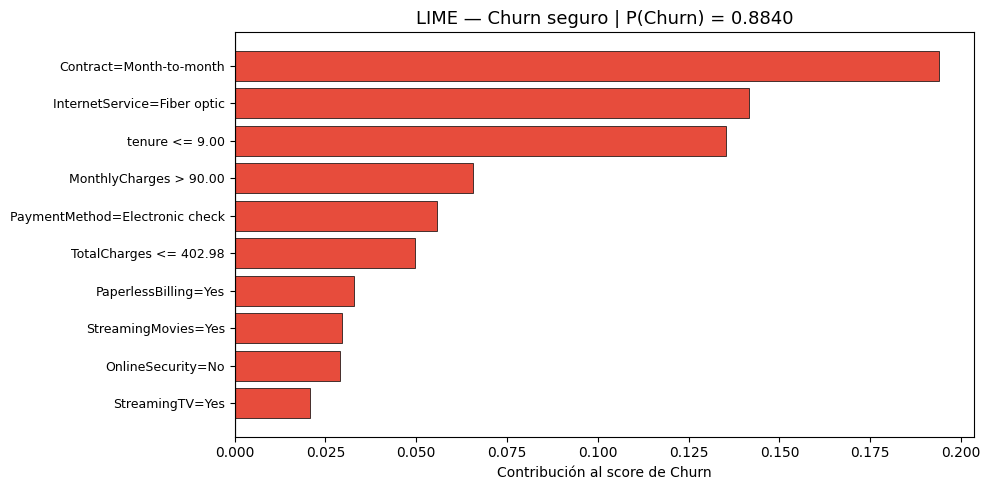

,Feature,Contribución,Dirección
0,Contract=Month-to-month,0.1939,Churn
1,InternetService=Fiber optic,0.1415,Churn
2,tenure <= 9.00,0.1354,Churn
3,MonthlyCharges > 90.00,0.0656,Churn
4,PaymentMethod=Electronic check,0.0556,Churn
5,TotalCharges <= 402.98,0.0496,Churn
6,PaperlessBilling=Yes,0.0329,Churn
7,StreamingMovies=Yes,0.0295,Churn
8,OnlineSecurity=No,0.0289,Churn
9,StreamingTV=Yes,0.0207,Churn


In [53]:
idx = casos['Churn seguro']

exp_churn = explainer.explain_instance(
    data_row   = X_test_lime[idx],   # numérico para LIME
    predict_fn = predict_fn_lime,    # decodifica y pasa al modelo
    num_features = 10,
    labels     = (1,)
)

print(f'Caso: Churn seguro | Índice: {idx}')
print(f'P(Churn) = {y_proba[idx]:.4f} | Real: {"Churn" if y_test.values[idx]==1 else "No Churn"}')
print()

features_vals = exp_churn.as_list(label=1)
feat_names = [f[0] for f in features_vals]
weights    = [f[1] for f in features_vals]
colors     = ['#e74c3c' if w > 0 else '#3498db' for w in weights]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(feat_names[::-1], weights[::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'LIME — Churn seguro | P(Churn) = {y_proba[idx]:.4f}', fontsize=13)
ax.set_xlabel('Contribución al score de Churn')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

df_exp = pd.DataFrame(features_vals, columns=['Feature', 'Contribución'])
df_exp['Dirección'] = df_exp['Contribución'].apply(lambda x: ' Churn' if x > 0 else ' No Churn')
display(df_exp)

> **Análisis:** Identificar las variables que más empujan hacia Churn. ¿Coinciden con el feature importance del notebook 2? ¿Tiene sentido de negocio?

### 5.2 Caso 2 — No Churn seguro

Caso: No Churn seguro | Índice: 1273
P(Churn) = 0.0584 | Real: No Churn



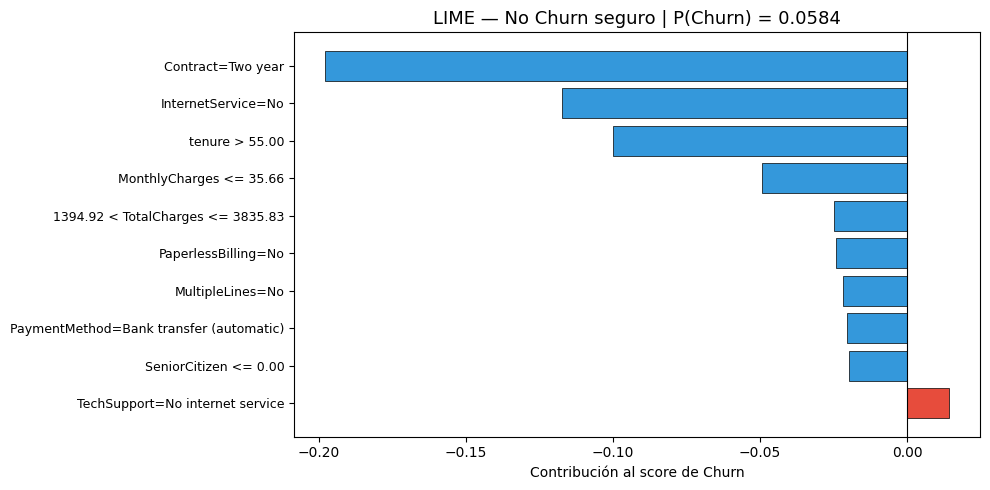

,Feature,Contribución,Dirección
0,Contract=Two year,-0.1978,No Churn
1,InternetService=No,-0.1174,No Churn
2,tenure > 55.00,-0.0999,No Churn
3,MonthlyCharges <= 35.66,-0.0493,No Churn
4,1394.92 < TotalCharges <= 3835.83,-0.0248,No Churn
5,PaperlessBilling=No,-0.0242,No Churn
6,MultipleLines=No,-0.0218,No Churn
7,PaymentMethod=Bank transfer (automatic),-0.0205,No Churn
8,SeniorCitizen <= 0.00,-0.0200,No Churn
9,TechSupport=No internet service,0.0141,Churn


In [58]:
idx = casos['No Churn seguro']

exp_no_churn = explainer.explain_instance(
    data_row   = X_test_lime[idx],
    predict_fn = predict_fn_lime,
    num_features = 10,
    labels     = (1,)
)

print(f'Caso: No Churn seguro | Índice: {idx}')
print(f'P(Churn) = {y_proba[idx]:.4f} | Real: {"Churn" if y_test.values[idx]==1 else "No Churn"}')
print()

features_vals = exp_no_churn.as_list(label=1)
feat_names = [f[0] for f in features_vals]
weights    = [f[1] for f in features_vals]
colors     = ['#e74c3c' if w > 0 else '#3498db' for w in weights]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(feat_names[::-1], weights[::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'LIME — No Churn seguro | P(Churn) = {y_proba[idx]:.4f}', fontsize=13)
ax.set_xlabel('Contribución al score de Churn')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

df_exp = pd.DataFrame(features_vals, columns=['Feature', 'Contribución'])
df_exp['Dirección'] = df_exp['Contribución'].apply(lambda x: ' Churn' if x > 0 else ' No Churn')
display(df_exp)

> **Análisis:** ¿Qué variables protegen a este cliente del churn? ¿Tiene contrato largo, tenure alto, pago automático? Contrastar con el Caso 1.

### 5.3 Caso 3 — Borderline

Caso: Borderline | Índice: 131
P(Churn) = 0.5001 | Real: Churn



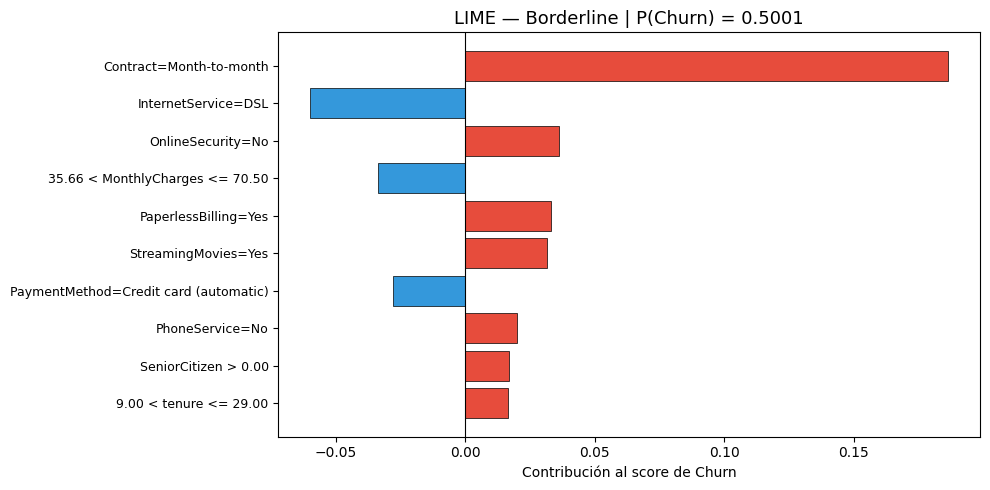

,Feature,Contribución,Dirección
0,Contract=Month-to-month,0.1864,Churn
1,InternetService=DSL,-0.0599,No Churn
2,OnlineSecurity=No,0.0361,Churn
3,35.66 < MonthlyCharges <= 70.50,-0.0337,No Churn
4,PaperlessBilling=Yes,0.0331,Churn
5,StreamingMovies=Yes,0.0313,Churn
6,PaymentMethod=Credit card (automatic),-0.0279,No Churn
7,PhoneService=No,0.0197,Churn
8,SeniorCitizen > 0.00,0.0170,Churn
9,9.00 < tenure <= 29.00,0.0165,Churn


In [59]:
idx = casos['Borderline']

exp_borderline = explainer.explain_instance(
    data_row   = X_test_lime[idx],
    predict_fn = predict_fn_lime,
    num_features = 10,
    labels     = (1,)
)

print(f'Caso: Borderline | Índice: {idx}')
print(f'P(Churn) = {y_proba[idx]:.4f} | Real: {"Churn" if y_test.values[idx]==1 else "No Churn"}')
print()

features_vals = exp_borderline.as_list(label=1)
feat_names = [f[0] for f in features_vals]
weights    = [f[1] for f in features_vals]
colors     = ['#e74c3c' if w > 0 else '#3498db' for w in weights]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(feat_names[::-1], weights[::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'LIME — Borderline | P(Churn) = {y_proba[idx]:.4f}', fontsize=13)
ax.set_xlabel('Contribución al score de Churn')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

df_exp = pd.DataFrame(features_vals, columns=['Feature', 'Contribución'])
df_exp['Dirección'] = df_exp['Contribución'].apply(lambda x: ' Churn' if x > 0 else ' No Churn')
display(df_exp)

> **Análisis:** En el caso borderline el modelo duda porque hay señales contradictorias. ¿Qué variables empujan en direcciones opuestas? ¿Hay factores de riesgo y de retención al mismo tiempo?

## 6. Análisis comparativo entre casos

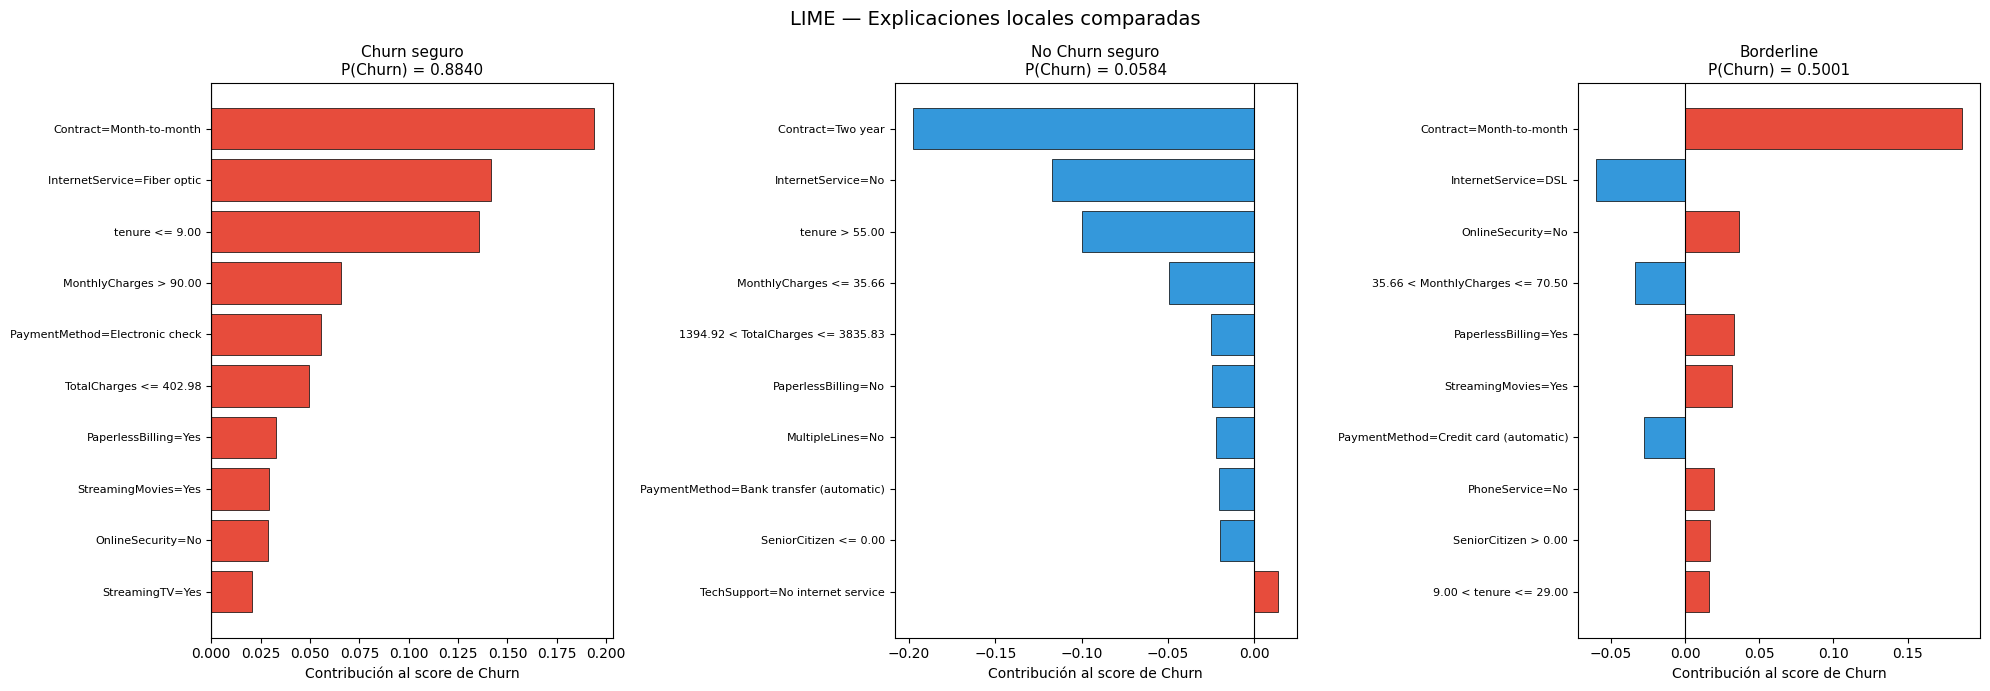

  Guardado en data/lime_comparacion.png


In [60]:
explicaciones = {
    'Churn seguro'   : (exp_churn,      casos['Churn seguro']),
    'No Churn seguro': (exp_no_churn,   casos['No Churn seguro']),
    'Borderline'     : (exp_borderline, casos['Borderline'])
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('LIME — Explicaciones locales comparadas', fontsize=14)

for ax, (nombre, (exp, idx)) in zip(axes, explicaciones.items()):
    features_vals = exp.as_list(label=1)
    feat_names = [f[0] for f in features_vals]
    weights    = [f[1] for f in features_vals]
    colors     = ['#e74c3c' if w > 0 else '#3498db' for w in weights]

    ax.barh(feat_names[::-1], weights[::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{nombre}\nP(Churn) = {y_proba[idx]:.4f}', fontsize=11)
    ax.set_xlabel('Contribución al score de Churn')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../data/lime_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Guardado en data/lime_comparacion.png')

In [62]:
# Tabla comparativa de contribuciones
dfs = []
for nombre, (exp, idx) in explicaciones.items():
    df_caso = pd.DataFrame(exp.as_list(label=1), columns=['Feature', nombre])
    df_caso = df_caso.set_index('Feature')
    dfs.append(df_caso)

df_comparacion = pd.concat(dfs, axis=1).fillna(0)
display(df_comparacion.style.background_gradient(cmap='RdBu_r', axis=None))

,Churn seguro,No Churn seguro,Borderline
Feature,,,
Contract=Month-to-month,0.193897,0.000000,0.186436
InternetService=Fiber optic,0.141501,0.000000,0.000000
tenure <= 9.00,0.135368,0.000000,0.000000
MonthlyCharges > 90.00,0.065580,0.000000,0.000000
PaymentMethod=Electronic check,0.055644,0.000000,0.000000
TotalCharges <= 402.98,0.049643,0.000000,0.000000
PaperlessBilling=Yes,0.032925,0.000000,0.033060
StreamingMovies=Yes,0.029504,0.000000,0.031340
OnlineSecurity=No,0.028863,0.000000,0.036114


> **Análisis:** Identificar las variables consistentes en los tres casos. ¿Hay variables que siempre empujan en la misma dirección? ¿Coincide con el feature importance global del notebook 2?

## 7. Conclusiones

> Completar con los hallazgos principales:
> - Variables que aparecen consistentemente como drivers de churn en los tres casos
> - Diferencias entre el perfil del cliente que hace churn vs el que no
> - ¿Las explicaciones locales de LIME son coherentes con la importancia global de features del notebook 2?
> - Implicaciones de negocio: ¿qué acciones concretas podría tomar la empresa? (ofrecer descuentos a clientes Month-to-month, incentivar pagos automáticos, etc.)
> - Limitaciones de LIME: aproximación local lineal, puede variar entre ejecuciones por la aleatoriedad de las perturbaciones